# **Практическая работа №5. Архитектуры CNN и Transfer Learning.ipynb**

## **Задание 1. Использование предобученной модели**

### **1.1. Выберите и импортируйте предобученную модель СНС для решения задач классификации из имеющихся в Keras: https://keras.io/api/applications/**

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# include_top=True  — включает полносвязные FC-слои и выходной слой на 1000 классов
# weights='imagenet' — веса, предобученные на датасете ImageNet
# classes=1000       — количество выходных классов (ImageNet)

model = keras.applications.VGG19(
    include_top=True,
    weights='imagenet',
    input_tensor=None,
    input_shape=None,       # по умолчанию (224, 224, 3)
    pooling=None,
    classes=1000,
    classifier_activation='softmax'
)

model.summary()

574710816/574710816 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,31

 Total params: 143,667,240 (548.05 MB)

 Trainable params: 143,667,240 (548.05 MB)

 Non-trainable params: 0 (0.00 B)

### **1.2. Загрузите из сети Интернет 5 изображений с разными классами, из тех, что приведены в [списке](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a), и сохраните их представление в список images**

In [ ]:
import cv2
from PIL import Image


image_urls = {
    "tabby_cat":       "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02123045_tabby.JPEG",
    "golden_retriever":"https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02099601_golden_retriever.JPEG",
    "banana":          "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n07753592_banana.JPEG",
    "elephant":        "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02504013_Indian_elephant.JPEG",
    "sports_car":      "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n04285008_sports_car.JPEG",
}

labels = list(image_urls.keys())
images = []

for label, url in image_urls.items():
    path = tf.keras.utils.get_file(fname=f"{label}.jpg", origin=url)
    img_pil = Image.open(path).convert("RGB")
    img_bgr = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
    images.append(img_bgr)
    print(f"{label}: {img_bgr.shape}")

print(f"\nВсего загружено: {len(images)} изображений")

86704/86704 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ tabby_cat: (500, 335, 3)
175825/175825 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ golden_retriever: (500, 300, 3)
188423/188423 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ banana: (374, 500, 3)
130273/130273 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ elephant: (333, 500, 3)
24243/24243 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ sports_car: (302, 563, 3)

Всего загружено: 5 изображений


### **1.3. Напишите функцию, принимающую на вход список с исходными изображениями и возвращающую список с преобразованными изображениями под формат входных данных выбранной Вами модели СНС (нормализация).**

(Не забудьте создать независимую копию исходного списка в теле функции, для обработки именно независимой копии, а не оригинального списка)

In [ ]:
from tensorflow.keras.applications import vgg16
from tensorflow.keras.applications.vgg16 import preprocess_input

def preprocess_images(images: list, target_size: tuple = (224, 224)) -> list:
    preprocessed = []

    for img in images:
        img_resized = cv2.resize(img, target_size)
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
        img_float = img_rgb.astype(np.float32)
        img_preprocessed = preprocess_input(img_float)
        preprocessed.append(img_preprocessed)
    return preprocessed

preprocessed_images = preprocess_images(images)

for i, (img, label) in enumerate(zip(preprocessed_images, labels)):
    print(f"[{i+1}] {label}: shape={img.shape}, dtype={img.dtype}, "
          f"min={img.min():.1f}, max={img.max():.1f}")

[1] tabby_cat: shape=(224, 224, 3), dtype=float32, min=-123.7, max=140.1
[2] golden_retriever: shape=(224, 224, 3), dtype=float32, min=-123.7, max=134.1
[3] banana: shape=(224, 224, 3), dtype=float32, min=-123.7, max=151.1
[4] elephant: shape=(224, 224, 3), dtype=float32, min=-111.7, max=151.1
[5] sports_car: shape=(224, 224, 3), dtype=float32, min=-123.7, max=151.1


### **1.5. Выведите изображения и соответствующие им классы (как в примере из теории)**

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


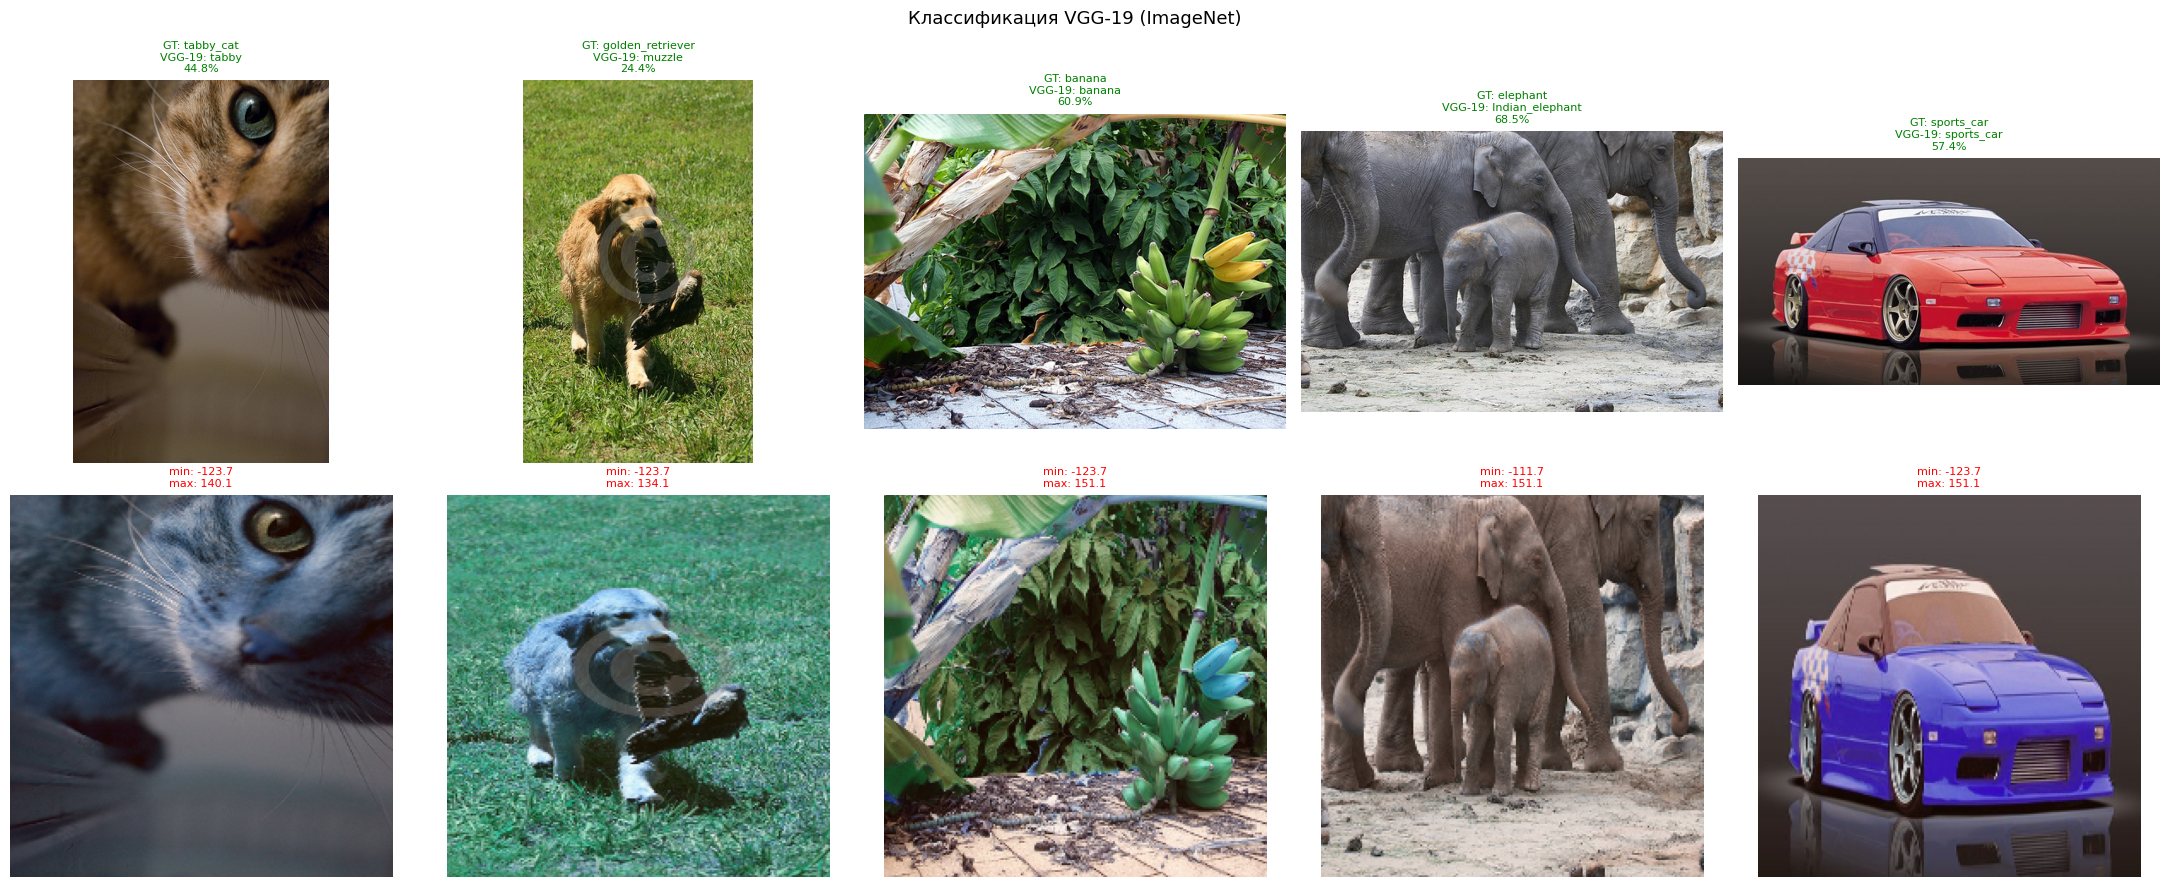

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg19 import decode_predictions

preprocessed_images = preprocess_images(images)

fig, axes = plt.subplots(2, 5, figsize=(22, 9))

for i, (img_original, img_pre, label) in enumerate(zip(images, preprocessed_images, labels)):

    img_batch = np.expand_dims(img_pre, axis=0)
    preds = model.predict(img_batch, verbose=0)
    top1 = decode_predictions(preds, top=1)[0][0]
    pred_class = top1[1]
    confidence  = top1[2] * 100

    # оригинальные изображения
    img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(
        f"GT: {label}\nVGG-19: {pred_class}\n{confidence:.1f}%",
        fontsize=8, color='green'
    )
    axes[0, i].axis('off')

    #  нормализованные изображения
    # Сдвигаем значения в [0, 1] для корректного отображения
    img_norm_vis = img_pre - img_pre.min()
    img_norm_vis = img_norm_vis / img_norm_vis.max()
    axes[1, i].imshow(img_norm_vis)
    axes[1, i].set_title(
        f"min: {img_pre.min():.1f}\nmax: {img_pre.max():.1f}",
        fontsize=8, color='red'
    )
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Оригинал", fontsize=10)
axes[1, 0].set_ylabel("Нормализованное", fontsize=10)

plt.suptitle("Классификация VGG-19 (ImageNet)", fontsize=13)
plt.tight_layout()
plt.show()

## **Задание 2. Использование обученной модели для работы со своим датасетом**

### **2.1. Выберите и импортируйте предобученную модель СНС для решения задач классификации из имеющихся в Keras: https://keras.io/api/applications/**

In [ ]:
help(tf.keras.applications)

Help on package tensorflow.keras.applications in tensorflow.keras:

NAME
    tensorflow.keras.applications - DO NOT EDIT.

DESCRIPTION
    This file was autogenerated. Do not edit it by hand,
    since your modifications would be overwritten.

PACKAGE CONTENTS
    convnext (package)
    densenet (package)
    efficientnet (package)
    efficientnet_v2 (package)
    imagenet_utils (package)
    inception_resnet_v2 (package)
    inception_v3 (package)
    mobilenet (package)
    mobilenet_v2 (package)
    mobilenet_v3 (package)
    nasnet (package)
    resnet (package)
    resnet50 (package)
    resnet_v2 (package)
    vgg16 (package)
    vgg19 (package)
    xception (package)

FILE
    /usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/applications/__init__.py




In [ ]:
!mkdir -p data
!curl -L -o data/flowers_dataset.zip "https://www.kaggle.com/api/v1/datasets/download/rahmasleam/flowers-dataset"
!unzip -q data/flowers_dataset.zip -d data/flowers_dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  218M  100  218M    0     0  90.1M      0  0:00:02  0:00:02 --:--:--  102M


In [ ]:
!find data/flowers_dataset -maxdepth 3 -type d

data/flowers_dataset
data/flowers_dataset/flower_photos
data/flowers_dataset/flower_photos/sunflowers
data/flowers_dataset/flower_photos/roses
data/flowers_dataset/flower_photos/daisy
data/flowers_dataset/flower_photos/tulips
data/flowers_dataset/flower_photos/dandelion


### **2.2. Подготовка тренировочных данных. Разделение на обучающую и тестовую выборку**

In [ ]:
data_dir = "data/flowers_dataset/flower_photos"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Классы ({num_classes}): {class_names}")

def normalize(x, y):
    x = x / 255.0
    return x, y

train_ds = train_ds.map(normalize)
val_ds = val_ds.map(normalize)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Классы (5): ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


### **2.3. Обучение своей модели на основе предобученной модели** "*название модели, выбранной в п.2.1.*"

In [ ]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout

base_model = VGG19(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False
aadadddd
model = Sequential([
    Input(shape=(224, 224, 3)),
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,156,997 (76.89 MB)

 Trainable params: 132,613 (518.02 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_vgg19.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor = 0.1, patience = 3, verbose = 1)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 338ms/step - accuracy: 0.3559 - loss: 1.4725 - val_accuracy: 0.5886 - val_loss: 1.3133 - learning_rate: 1.0000e-04
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 329ms/step - accuracy: 0.4663 - loss: 1.3375 - val_accuracy: 0.6390 - val_loss: 1.2067 - learning_rate: 1.0000e-04
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 328ms/step - accuracy: 0.5283 - loss: 1.2383 - val_accuracy: 0.6580 - val_loss: 1.1207 - learning_rate: 1.0000e-04
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 333ms/step - accuracy: 0.5971 - loss: 1.1336 - val_accuracy: 0.6853 - val_loss: 1.0564 - learning_rate: 1.0000e-04
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 333ms/step - accuracy: 0.6301 - loss: 1.0642 - val_accuracy: 0.6989 - val_loss: 1.0015 - learning_rate: 1.0000e-04
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 331ms/step - accuracy: 0.6512 - loss: 1.0163 - val_accuracy: 0.7044 - val_loss: 0.9526 - learning_rate: 1.0000e-04
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 331ms/step - acc

### **2.4. Визуализация процесса обучения модели**

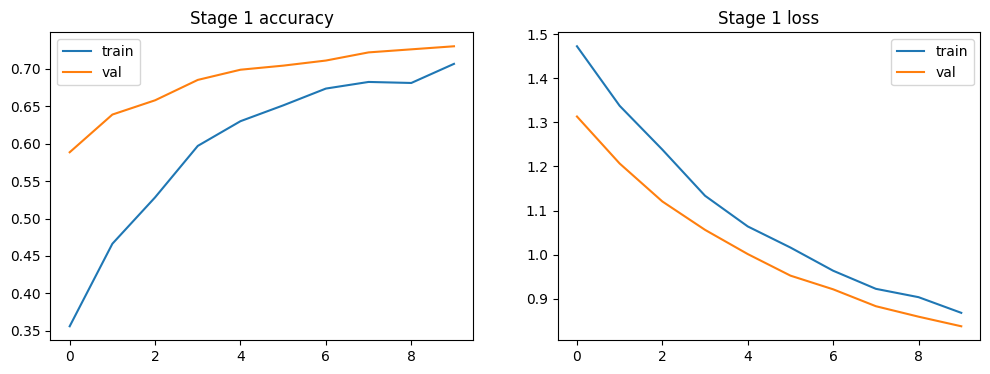

NameError: name 'history_ft' is not defined

In [ ]:
def plot_history(h, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(h.history["accuracy"], label="train")
    plt.plot(h.history["val_accuracy"], label="val")
    plt.title(title + " accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(h.history["loss"], label="train")
    plt.plot(h.history["val_loss"], label="val")
    plt.title(title + " loss")
    plt.legend()
    plt.show()

plot_history(history, "Stage 1")

### **2.5. Подготовьте набор проверочных данных (examples)**

In [ ]:
examples = []

for x_batch, y_batch in val_ds.take(1):
    for i in range(len(x_batch)):
        examples.append({
            "image": x_batch[i].numpy(),
            "label": class_names[int(y_batch[i])]  # истинный класс
        })

print(f"Примеров: {len(examples)}")
print(f"Пример 0: shape={examples[0]['image'].shape}, label={examples[0]['label']}")

Примеров: 32
Пример 0: shape=(224, 224, 3), label=tulips


### **2.6. Реализуйте графический интерфейс для взаимодействия с обученной моделью, используя [Gradio](https://www.gradio.app/guides/image-classification-in-tensorflow) или люое другое решение.**



Если выбрали Gradio, то в качестве примеров (параметр examples в Gradio), используйте изображения из списка images (п.1.2.)

In [ ]:
!pip -q install gradio

import gradio as gr

def predict(image):
    # Ресайз и нормализация
    img = tf.image.resize(image, (224, 224))
    img = img / 255.0
    img = tf.expand_dims(img, axis=0)  # (1, 224, 224, 3)


    preds = model.predict(img, verbose=0)[0]

    # Словарь класс-вероятность
    return {class_names[i]: float(preds[i]) for i in range(len(class_names))}


# Примеры для интерфейса берём по одному на каждый класс
example_images = []
for cls in class_names:
    for ex in examples:
        if ex["label"] == cls:
            # Обратно в [0-255] uint8
            img_uint8 = (ex["image"] * 255).astype(np.uint8)
            example_images.append(img_uint8)
            break


demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(label="Загрузите фото цветка"),
    outputs=gr.Label(num_top_classes=len(class_names), label="Классификация VGG-19"),
    title="🌸 Распознавание цветов — VGG-19",
    description="Загрузите изображение цветка. Модель определит его класс.",
    examples=[[img] for img in example_images]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b7edfdd320ab1573b1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## **Задание 3. Классификация набора пространственных данных EuroSat (для магистров)**

- Ссылка на датасет: https://github.com/phelber/eurosat

- Описание на kaggle: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset

В этом задании Вам будет предоставлен набор данных EuroSat, который содержит снимки земной поверхности, снятые спутником Sentinel-2. Вам нужно будет обучить модель для классификации этих изображений на 10 классов, представляющих различные типы земного покрова.

### **3.1. Загрузка данных:**
  * [Скачайте](https://madm.dfki.de/files/sentinel/EuroSAT.zip) набор данных EuroSat
  * Разделите данные на обучающую, валидационную и тестовую выборки.



In [ ]:
import tensorflow as tf
import numpy as np
import os


!mkdir -p data
!curl -k -L -o data/EuroSAT.zip "https://madm.dfki.de/files/sentinel/EuroSAT.zip"
!unzip -q data/EuroSAT.zip -d data/



  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 89.9M  100 89.9M    0     0  14.6M      0  0:00:06  0:00:06 --:--:-- 18.3M
replace data/2750/River/River_479.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: data/2750
data/2750/Forest
data/2750/Highway
data/2750/PermanentCrop
data/2750/Pasture
data/2750/HerbaceousVegetation
data/2750/Industrial
data/2750/River
data/2750/SeaLake
data/2750/Residential
data/2750/AnnualCrop


In [ ]:

!find data/2750 -maxdepth 2 -type d

data/2750
data/2750/Forest
data/2750/Highway
data/2750/PermanentCrop
data/2750/Pasture
data/2750/HerbaceousVegetation
data/2750/Industrial
data/2750/River
data/2750/SeaLake
data/2750/Residential
data/2750/AnnualCrop


In [ ]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32
SEED = 42


train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/2750",
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)


val_test_ds = tf.keras.utils.image_dataset_from_directory(
    "data/2750",
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Классы ({num_classes}): {class_names}")

val_batches  = tf.data.experimental.cardinality(val_test_ds) // 2
val_ds   = val_test_ds.take(val_batches)
test_ds  = val_test_ds.skip(val_batches)

print(f"Train батчей:  {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Val батчей:    {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Test батчей:   {tf.data.experimental.cardinality(test_ds).numpy()}")

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Классы (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Train батчей:  591
Val батчей:    127
Test батчей:   127


### **3.2. Выбор архитектуры нейронной сети:**
  * Выберите архитектуру нейронной сети, основанную на трансферном обучении, например, ResNet50, VGG16 или InceptionV3 ([полный список](https://keras.io/api/applications/)).
  * Загрузите предобученную модель выбранной архитектуры.


In [ ]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras import layers, models

base_model = VGG19(
    include_top=False,
    weights="imagenet",
    input_shape=(64, 64, 3)
)
base_model.trainable = False

print(f"Слоёв в VGG19: {len(base_model.layers)}")
base_model.summary()

Слоёв в VGG19: 22


Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,024,384 (76.39 MB)

### **3.3. Дообучение модели:**
  * Добавьте к предобученной модели несколько слоев для классификации изображений EuroSat.
  * Обучите модель на обучающей выборке.

In [ ]:
model = Sequential([
    Input(shape=(64, 64, 3)),
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_vgg19.keras",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 35s 43ms/step - accuracy: 0.4854 - loss: 5.5180 - val_accuracy: 0.7859 - val_loss: 1.1575
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.6898 - loss: 1.8398 - val_accuracy: 0.8199 - val_loss: 0.7793
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - accuracy: 0.7408 - loss: 1.2231 - val_accuracy: 0.8381 - val_loss: 0.6146
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.7626 - loss: 0.9379 - val_accuracy: 0.8497 - val_loss: 0.5387
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.7846 - loss: 0.7743 - val_accuracy: 0.8548 - val_loss: 0.4994
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.8047 - loss: 0.6782 - val_accuracy: 0.8620 - val_loss: 0.4740
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.8185 - loss: 0.6067 - val_accuracy: 0.8676 - val_loss: 0.4459
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.8284 - loss: 0.5601 - 



### **3.4. Оценка модели:**
  * Оцените производительность модели на валидационной и тестовой выборках.
  * Сравните результаты с другими архитектурами нейронных сетей.



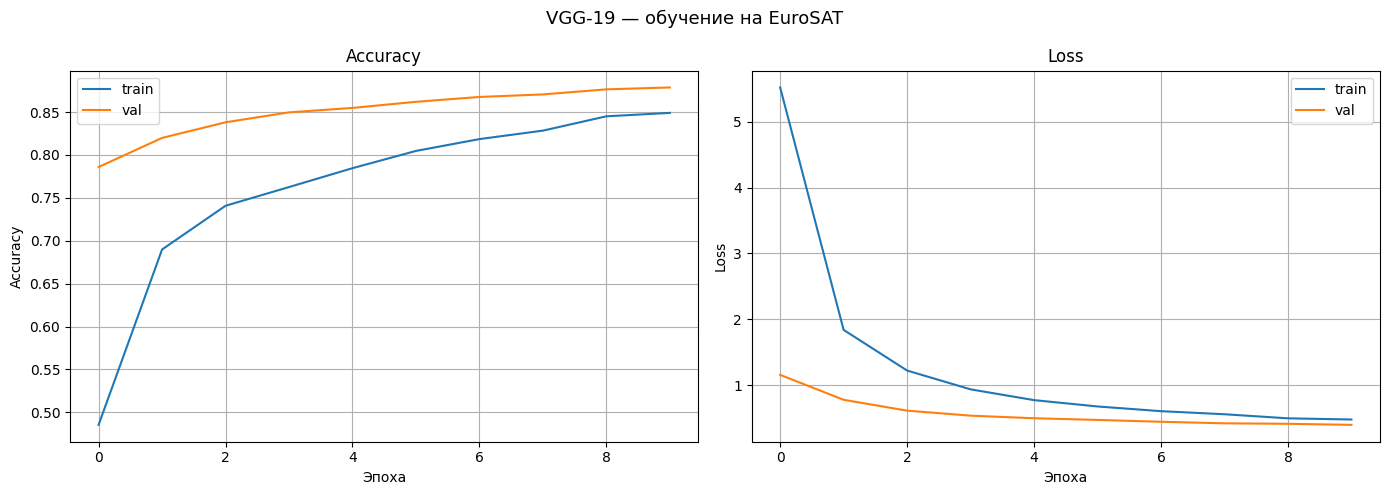

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(history.history["accuracy"],     label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)


axes[1].plot(history.history["loss"],     label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("VGG-19 — обучение на EuroSAT", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
val_loss, val_acc = model.evaluate(val_ds, verbose=1)
print(f"\nVal  accuracy: {val_acc:.4f}  |  Val  loss: {val_loss:.4f}")

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test accuracy: {test_acc:.4f}  |  Test loss: {test_loss:.4f}")

127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8780 - loss: 0.3993

Val  accuracy: 0.8780  |  Val  loss: 0.3993
127/127 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.8724 - loss: 0.3906
Test accuracy: 0.8724  |  Test loss: 0.3906


| Архитектура         | Val Accuracy | Test Accuracy | Размер модели | Скорость  |
| ------------------- | ------------ | ------------- | ------------- | --------- |
| VGG19 (наша модель) | 0.8780       | 0.8724        | 150 MB        | медленная |
| VGG16               | ~0.88–0.98   | ~0.87–0.97    | 138 MB        | медленная |
| MobileNetV2         | ~0.96        | ~0.95         | 9 MB          | быстрая   |
| InceptionV3         | ~0.95        | ~0.94         | 92 MB         | средняя   |
| ResNet50            | ~0.90–0.93   | ~0.89–0.92    | 98 MB         | средняя   |

### **3.5. Анализ результатов:**
  * Проанализируйте влияние различных параметров на производительность модели, таких как:
      * Количество эпох обучения
      * Размер пакета
      * Функция активации
      * Оптимизатор
      * Регуляризация

Количество эпох.
При малом числе эпох (3–5) модель не успевает сойтись — точность остаётся низкой, не успевает обучиться. Увеличение до 10–15 эпох даёт прирост точности, но при дальнейшем росте ранняя остановка всё равно остановит обучение, как только точность перестанет улучшаться.

Размер пакета
Маленький батч (16) даёт более точную оценку градиента на каждом шаге и модель обучается стабильнее, но медленнее. Большой batch (64 и выше) ускоряет обучение, но градиент становится усреднённым по большему числу примеров, что может привести к попаданию в плохой локальный минимум и снижению итоговой точности.

Функция активации
relu — стандартный выбор для  подоюбных задач и обычно даёт лучший результат. tanh работает хуже из-за затухания градиентов.

Оптимизатор
adam адаптивно подбирает скорость обучения для каждого параметра. rmsprop ведёт себя схоже, но менее стабилен. sgd  сходится значительно медленнее.

Дропаут
Слишком маленький дропаут (0.2) не защищает от переобучения — валидационная точность начинает отставать от тренировочной. Слишком большой (0.7) слишком ограничивает обучение и снижает итоговую точность. Значение 0.5 -нормальный компромисс.

-----------------------------------------
**Ваш вывод**
-----------------------------------------


В ходе работы я узнал, как подключить уже готовую обученную умными людьми нейронку, дообучить ее на своих данных и применять в своих задачах. Получилось неплохо - вроде как это самая большая точность которой я добился.